### Part One

In [3]:
# import necessary  libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# a. Load the data in “Gene_Expression_Data.xlsx”, “Gene_Information.csv”, and “Sample_Information.tsv” into Python
gene_exp = pd.read_excel("C:/Users/icwin/OneDrive - Indiana University/[B-573] Prog. Sci-Informatics/Python/Gene_Expression_Data.xlsx")
gene_info = pd.read_csv("C:/Users/icwin/OneDrive - Indiana University/[B-573] Prog. Sci-Informatics/Python/Gene_Information.csv")
samp_info = pd.read_csv("C:/Users/icwin/OneDrive - Indiana University/[B-573] Prog. Sci-Informatics/Python/Sample_Information.tsv", sep='\t')

In [5]:
# b. Change the sample names from the “Gene_Expression_Data.xlsx”, based upon the phenotype presented in “Sample_Information.tsv”
sample_name_mapping = {
    'GSM820516': 'tumor_1',
    'GSM820517': 'normal_1',
    'GSM820518': 'tumor_2',
    'GSM820519': 'normal_2',
    'GSM820520': 'tumor_3',
    'GSM820521': 'normal_3',
    'GSM820522': 'tumor_4',
    'GSM820523': 'normal_4',
    'GSM820524': 'tumor_5',
    'GSM820525': 'normal_5',
    'GSM820526': 'tumor_6',
    'GSM820527': 'normal_6',
    'GSM820528': 'tumor_7',
    'GSM820529': 'normal_7',
    'GSM820530': 'tumor_8',
    'GSM820531': 'normal_8',
    'GSM820532': 'tumor_9',
    'GSM820533': 'normal_9'
}
gene_exp.columns = gene_exp.columns.to_series().replace(sample_name_mapping)

In [6]:
# c. Split the merged data from part b, into to 2 parts, based upon their labeled phenotype
probe_id = gene_exp.columns[0]
gene_exp_tumor = gene_exp.loc[:, gene_exp.columns.str.contains('tumor') | (gene_exp.columns == probe_id)]
gene_exp_normal = gene_exp.loc[:, gene_exp.columns.str.contains('normal') | (gene_exp.columns == probe_id)]

In [7]:
# d. Compute the average expression for each probe from the 2 data sets from part c
gene_exp_normal["probe_id_avg_norm"] = gene_exp_normal.iloc[:, 1:].mean(axis = 1)
gene_exp_tumor["probe_id_avg_tumor"] = gene_exp_tumor.iloc[:, 1:].mean(axis = 1)

C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\1994086955.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_exp_normal["probe_id_avg_norm"] = gene_exp_normal.iloc[:, 1:].mean(axis = 1)
C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\1994086955.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_exp_tumor["probe_id_avg_tumor"] = gene_exp_tumor.iloc[:, 1:].mean(axis = 1)


In [8]:
# e. Determine the fold change for each probe between the two groups ((Tumour – Control) / Control)
gene_exp_normal["fold_change"] = (gene_exp_tumor["probe_id_avg_tumor"] - gene_exp_normal["probe_id_avg_norm"]) / gene_exp_normal["probe_id_avg_norm"]
gene_exp_tumor["fold_change"] = (gene_exp_tumor["probe_id_avg_tumor"] - gene_exp_normal["probe_id_avg_norm"]) / gene_exp_normal["probe_id_avg_norm"]


C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\906340446.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_exp_normal["fold_change"] = (gene_exp_tumor["probe_id_avg_tumor"] - gene_exp_normal["probe_id_avg_norm"]) / gene_exp_normal["probe_id_avg_norm"]
C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\906340446.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_exp_tumor["fold_change"] = (gene_exp_tumor["probe_id_avg_tumor"] - gene_exp_normal["probe_id_avg_norm"]) / gene_exp_normal["probe_id_

In [9]:
# f. Use the data from part e and “Gene_Information.csv” to identify all genes fold change magnitude (absolute value) was greater than 5
gene_exp_normal["Gene_Name"] = gene_info["Symbol"]
gene_exp_normal["abs_fold_change"] = abs(gene_exp_normal["fold_change"])
gene_exp_normal["significant"] = np.where(gene_exp_normal["abs_fold_change"] > 5, "Yes", "No")

gene_exp_tumor["Gene_Name"] = gene_info["Symbol"]
gene_exp_tumor["abs_fold_change"] = abs(gene_exp_tumor["fold_change"])
gene_exp_tumor["significant"] = np.where(gene_exp_tumor["abs_fold_change"] > 5, "Yes", "No")

C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\2624655685.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_exp_normal["Gene_Name"] = gene_info["Symbol"]
C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\2624655685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_exp_normal["abs_fold_change"] = abs(gene_exp_normal["fold_change"])
C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\2624655685.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [10]:
gene_exp
gene_exp["probe_id_avg_tumor"] = gene_exp_tumor["probe_id_avg_tumor"]
gene_exp["fold_change"] = gene_exp_tumor["fold_change"]
gene_exp["Gene_Name"] = gene_exp_tumor["Gene_Name"]
gene_exp["abs_fold_change"] = gene_exp_tumor["abs_fold_change"]
gene_exp["significant"] = gene_exp_tumor["significant"]
gene_exp["higher_expressed"] = np.where(gene_exp["fold_change"] > 0, "tumor", "normal")

In [11]:
# g. Add a column to the result of part f to include if the gene was higher expressed in “Normal” or “Tumor” samples
# create sub table with all needed info
gene_exp['abs_fold_change'] = gene_exp['fold_change'].abs()  
sub_gene_exp = gene_exp[gene_exp["abs_fold_change"] > 5]
sub_gene_exp["probe_id_avg_tumor"] = gene_exp_tumor["probe_id_avg_tumor"]
sub_gene_exp["fold_change"] = gene_exp_tumor["fold_change"]
sub_gene_exp["Gene_Name"] = gene_exp_tumor["Gene_Name"]
sub_gene_exp["abs_fold_change"] = gene_exp_tumor["abs_fold_change"]
sub_gene_exp["significant"] = gene_exp_tumor["significant"]
sub_gene_exp["higher_expressed"] = np.where(sub_gene_exp["fold_change"] > 0, "tumor", "normal")

sub_gene_exp

C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\137203892.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_gene_exp["probe_id_avg_tumor"] = gene_exp_tumor["probe_id_avg_tumor"]
C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\137203892.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_gene_exp["fold_change"] = gene_exp_tumor["fold_change"]
C:\Users\icwin\AppData\Local\Temp\ipykernel_15572\137203892.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

,Probe_ID,tumor_1,normal_1,tumor_2,normal_2,tumor_3,normal_3,tumor_4,normal_4,tumor_5,...,tumor_8,normal_8,tumor_9,normal_9,probe_id_avg_tumor,fold_change,Gene_Name,abs_fold_change,significant,higher_expressed
46,ILMN_1651354,263.7130,2152.1880,27479.8100,441.8127,286.4274,741.8279,1672.9440,502.5659,842.1483,...,826.2133,545.1593,16409.8500,299.4235,5569.856956,5.453412,SPP1,5.453412,Yes,tumor
1077,ILMN_1655915,877.0667,493.2354,8936.1080,695.5372,3809.3260,381.9552,3179.1800,538.9714,15987.7200,...,1839.8750,724.9558,4400.1680,467.0362,4949.759489,8.238199,MMP11,8.238199,Yes,tumor
3481,ILMN_1666733,2907.1870,1103.2410,8392.2110,402.4640,10110.8700,317.9082,2061.5980,808.6967,14893.2300,...,2066.5590,403.0264,3030.1260,338.3966,5967.483111,10.479637,IL8,10.479637,Yes,tumor
3949,ILMN_1669046,23593.6100,326.3106,3465.2370,372.4652,7037.6630,259.1707,15407.0800,509.6685,18377.5200,...,9287.7230,339.4519,1004.5330,228.5419,10719.899111,29.304799,FOXQ1,29.304799,Yes,tumor
6505,ILMN_1681260,306.8056,227.2110,6689.5230,214.3888,452.2915,237.0134,330.5530,225.3090,1328.5380,...,909.6605,236.8212,715.1674,242.4231,1787.026600,6.484814,LOC643272,6.484814,Yes,tumor
6537,ILMN_1681462,1703.5730,225.3520,594.6810,190.9300,354.7823,232.9796,205.6378,186.1783,4633.0070,...,373.5381,202.3787,196.6109,182.7645,9065.138122,43.570323,REG1B,43.570323,Yes,tumor
7309,ILMN_1685403,19607.6400,217.0357,2133.3070,367.5093,1040.9450,263.9724,4797.7920,224.6817,5790.9810,...,2059.1320,210.3694,1313.2510,232.0900,7246.699000,25.354954,MMP7,25.354954,Yes,tumor
7656,ILMN_1687319,405.0292,179.3568,2021.1510,181.2526,216.8601,200.3208,4571.0210,214.1966,2837.5630,...,1946.1910,209.3041,194.7623,171.3451,1499.093578,6.655098,SLCO1B3,6.655098,Yes,tumor
8620,ILMN_1692223,70519.1100,4010.0440,40825.2300,4537.0180,50168.6000,9827.6820,57982.9000,4583.8280,12310.3000,...,68680.3100,8740.8760,12090.1800,12357.5600,47298.018889,5.241923,LCN2,5.241923,Yes,tumor
9311,ILMN_1695924,3569.4240,283.2978,3853.6370,427.7145,300.9037,315.4711,6598.3010,741.7113,314.5590,...,1590.6500,327.5567,487.9199,292.7081,3695.053567,8.374528,KLK11,8.374528,Yes,tumor


### Part 2

In [12]:
# a. Perform exploratory data analysis on the genes from part 1g
gene_exp_normal.head()
gene_exp_normal.info()
gene_exp_normal.describe()

gene_exp_tumor.head()
gene_exp_tumor.info()
gene_exp_tumor.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48803 entries, 0 to 48802
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Probe_ID           48803 non-null  object 
 1   normal_1           48803 non-null  float64
 2   normal_2           48803 non-null  float64
 3   normal_3           48803 non-null  float64
 4   normal_4           48803 non-null  float64
 5   normal_5           48803 non-null  float64
 6   normal_6           48803 non-null  float64
 7   normal_7           48803 non-null  float64
 8   normal_8           48803 non-null  float64
 9   normal_9           48803 non-null  float64
 10  probe_id_avg_norm  48803 non-null  float64
 11  fold_change        48803 non-null  float64
 12  Gene_Name          36157 non-null  object 
 13  abs_fold_change    48803 non-null  float64
 14  significant        48803 non-null  object 
dtypes: float64(12), object(3)
memory usage: 5.6+ MB
<class 'pandas.core.fr

,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,probe_id_avg_tumor,fold_change,abs_fold_change
count,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000,48803.000000
mean,1247.095952,1247.054939,1247.081206,1247.112999,1247.149325,1247.086354,1247.124502,1247.043581,1247.119429,1247.096476,0.043414,0.142904
std,4647.317905,4647.325629,4647.321376,4647.314552,4647.306591,4647.320332,4647.312270,4647.327127,4647.312329,4500.940309,0.578126,0.561866
min,137.418400,132.615000,132.615000,132.615000,132.615000,132.615000,132.615000,132.615000,132.615000,165.185356,-0.982875,0.000001
25%,212.073250,212.042200,212.007600,212.080200,212.120150,211.985900,212.086550,212.071400,212.085100,214.421767,-0.044016,0.022038
50%,244.877500,244.864200,244.931500,244.939400,244.959900,244.931500,244.966600,244.888500,245.000000,244.931922,0.003493,0.050998
75%,508.239200,508.034300,508.239200,508.239200,508.239200,508.299350,508.299350,507.735650,508.108600,544.853928,0.059799,0.136262
max,71775.300000,71775.300000,71775.300000,71775.300000,71775.300000,71775.300000,71775.300000,71775.300000,71775.300000,69373.551111,43.570323,43.570323


<Axes: xlabel='Chromosome'>

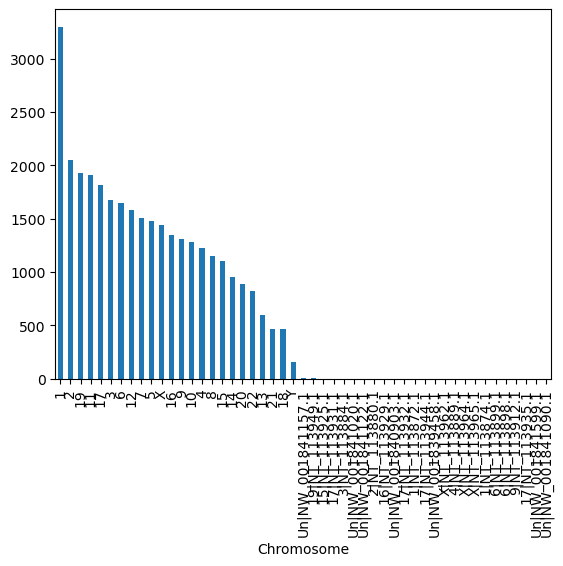

In [13]:
# b. Create a histogram showing the distribution of the number of differentially expressed genes (DEGs) by chromosome
probe_id = gene_exp["Probe_ID"]
get = gene_info["Probe_ID"].isin(probe_id)
genes_inf_2 = gene_info[get]
genes_inf_2["Chromosome"].value_counts().plot(kind='bar')

<Axes: xlabel='Chromosome'>

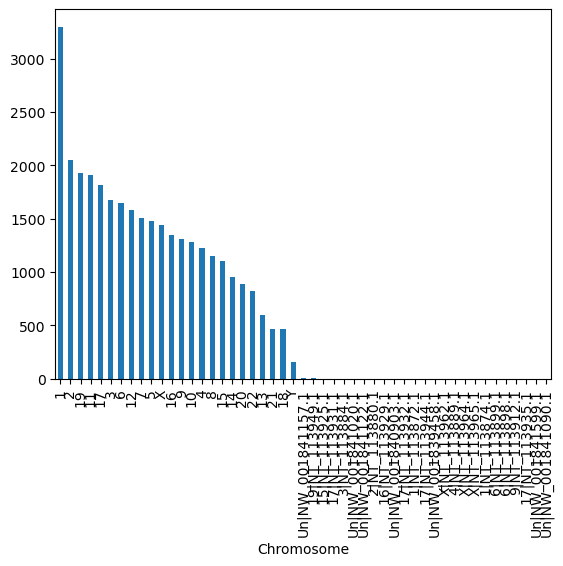

In [ ]:
# c. Make another histogram showing the distribution of DEGs by chromosome segregated by sample type (Normal or Tumor)
tumor_gene_exp = gene_exp[gene_exp["higher_expressed"] == "tumor"]
get = gene_info["Probe_ID"].isin(probe_id)
genes_inf_2 = gene_info[get]
genes_inf_2["Chromosome"].value_counts().plot(kind='bar')

normal_gene_exp = gene_exp[gene_exp["higher_expressed"] == "normal"]
get = gene_info["Probe_ID"].isin(probe_id)
genes_inf_2 = gene_info[get]
genes_inf_2["Chromosome"].value_counts().plot(kind='bar')


<Axes: xlabel='higher_expressed'>

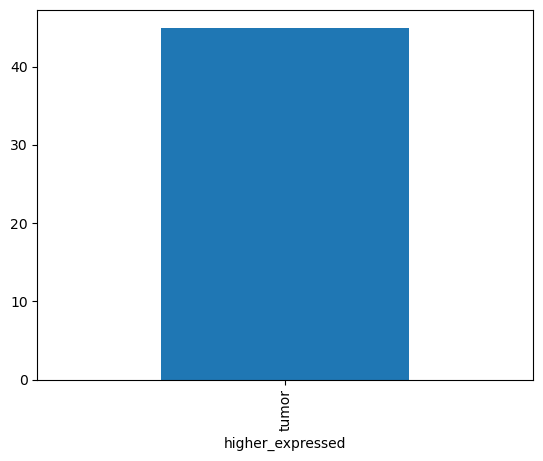

In [23]:
# d. Create a bar chart showing the percentages of the DEGs that are upregulated (higher) in Tumor samples and down regulated (lower) in Tumor samples
sub_gene_exp["higher_expressed"].value_counts().plot(kind='bar')

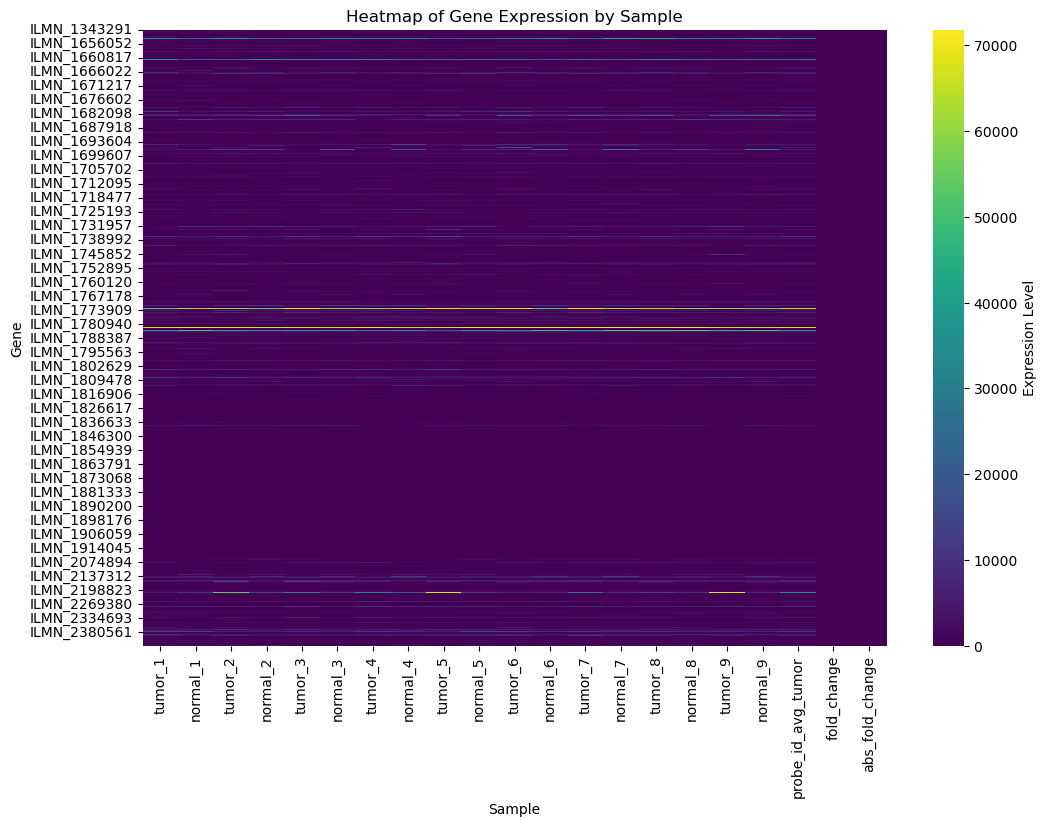

In [26]:
# e. Use the raw data from part 1b to create a heatmap visualizing gene expression by sample
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_data = gene_exp.set_index('Probe_ID').select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis', cbar_kws={'label': 'Expression Level'})
plt.title('Heatmap of Gene Expression by Sample')
plt.xlabel('Sample')
plt.ylabel('Gene')
plt.show()

<Figure size 1200x800 with 0 Axes>

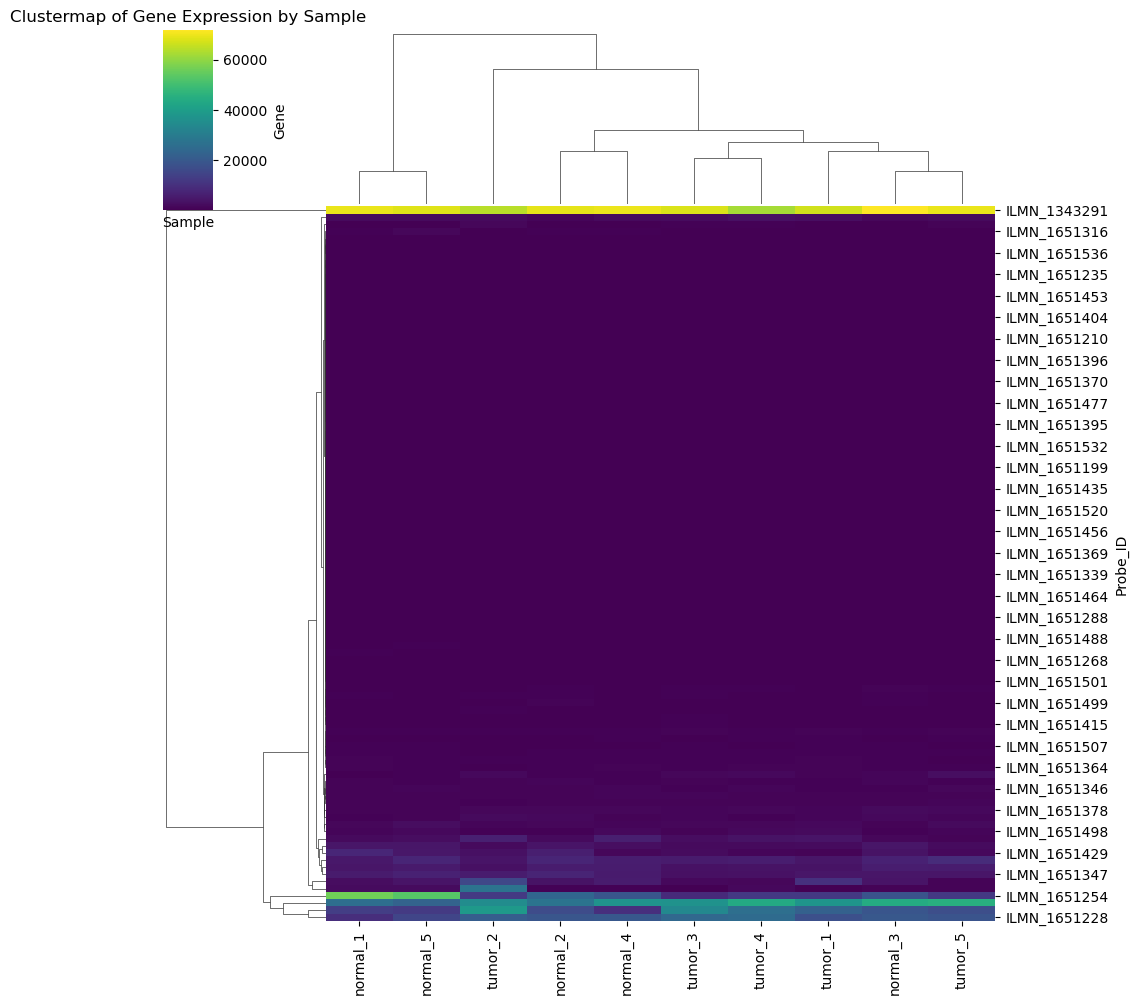

In [ ]:
# f. Use the same data from the previous part to create a clustermap visualizing gene expression by sample
plt.figure(figsize=(12, 8))
reduced_heatmap_data = heatmap_data.iloc[:100, :10]
sns.clustermap(reduced_heatmap_data, cmap='viridis', cbar_kws={'label': 'Expression Level'})
plt.title('Clustermap of Gene Expression by Sample')
plt.xlabel('Sample')
plt.ylabel('Gene')
plt.show()

For part 2 of this assigment I focused on the different expression of genes for the tumor and normal samples. By calculating the fold change and absolute fold change, I was able to see the difference in tumor samples compared to normal samples. The bar chart visualized the amount of differently expressed genes that were upregulated and downregulated in the tumor samples. This showed that many genes in the tumor samples were upregulated. Also the heatmap was a good way to show the differnt gene expression levels in teh datas. All these findings suggest that specific genes can play crucial roles in tumor development.